In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
df = pd.read_csv("data/summary_stats.csv", parse_dates=["dt"])
df.head()

,_id,dt,reported_trips_started,trips_started_wav,trips_started_nonwav,trips_started_pooled,trips_cancelled_driver_wav,trips_cancelled_driver_nonwav,trips_cancelled_passenger_wav,trips_cancelled_passenger_nonwav,...,dist_enroute_routed,dist_ontrip_routed,dist_ontrip_reported,percent_time_available,percent_time_enroute,percent_time_waiting,percent_time_ontrip,percent_dist_available_routed,percent_dist_enroute_routed,percent_dist_ontrip_routed
0,1,2018-01-01,117390,102,117288,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2018-01-02,71260,118,71142,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2018-01-03,74204,89,74115,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2018-01-04,87341,105,87236,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2018-01-05,117752,135,117617,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df[df["dt"] >= "2020-01-01"].sort_values("dt").reset_index(drop=True)
df.head()

,_id,dt,reported_trips_started,trips_started_wav,trips_started_nonwav,trips_started_pooled,trips_cancelled_driver_wav,trips_cancelled_driver_nonwav,trips_cancelled_passenger_wav,trips_cancelled_passenger_nonwav,...,dist_enroute_routed,dist_ontrip_routed,dist_ontrip_reported,percent_time_available,percent_time_enroute,percent_time_waiting,percent_time_ontrip,percent_dist_available_routed,percent_dist_enroute_routed,percent_dist_ontrip_routed
0,731,2020-01-01,192453,78,192375,13407.0,2.0,5464.0,10.0,9444.0,...,146593.62,1630967.17,2002171.26,34.88,6.88,6.69,51.55,28.08,5.93,65.99
1,732,2020-01-02,122471,114,122357,7936.0,3.0,1182.0,15.0,2563.0,...,68006.27,930261.03,1083097.68,59.80,3.50,4.39,32.30,44.91,3.75,51.33
2,733,2020-01-03,150928,111,150817,8612.0,1.0,1351.0,3.0,3236.0,...,78488.35,1116547.02,1293300.01,58.43,3.39,4.56,33.62,43.50,3.71,52.79
3,734,2020-01-04,166225,75,166150,9737.0,4.0,1770.0,6.0,3878.0,...,82768.82,1245669.54,1452138.52,57.18,3.30,4.80,34.73,42.46,3.58,53.95
4,735,2020-01-05,142739,59,142680,9435.0,1.0,1832.0,7.0,3579.0,...,85458.78,1123340.48,1313837.39,50.51,4.42,5.35,39.71,38.40,4.36,57.25


In [4]:
# Flag known missing data periods so they don't create misleading flat lines
missing_dates = pd.to_datetime([
    "2021-10-07", "2021-10-08", "2021-10-09",
    "2021-10-14", "2021-10-15", "2021-10-16",
    "2025-05-26", "2025-05-27", "2025-05-28",
])
df.loc[df["dt"].isin(missing_dates), :] = pd.NA
df["dt"] = pd.to_datetime(df["dt"])  # restore dt after NA assignment

In [5]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": (12, 4)})

def fmt_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

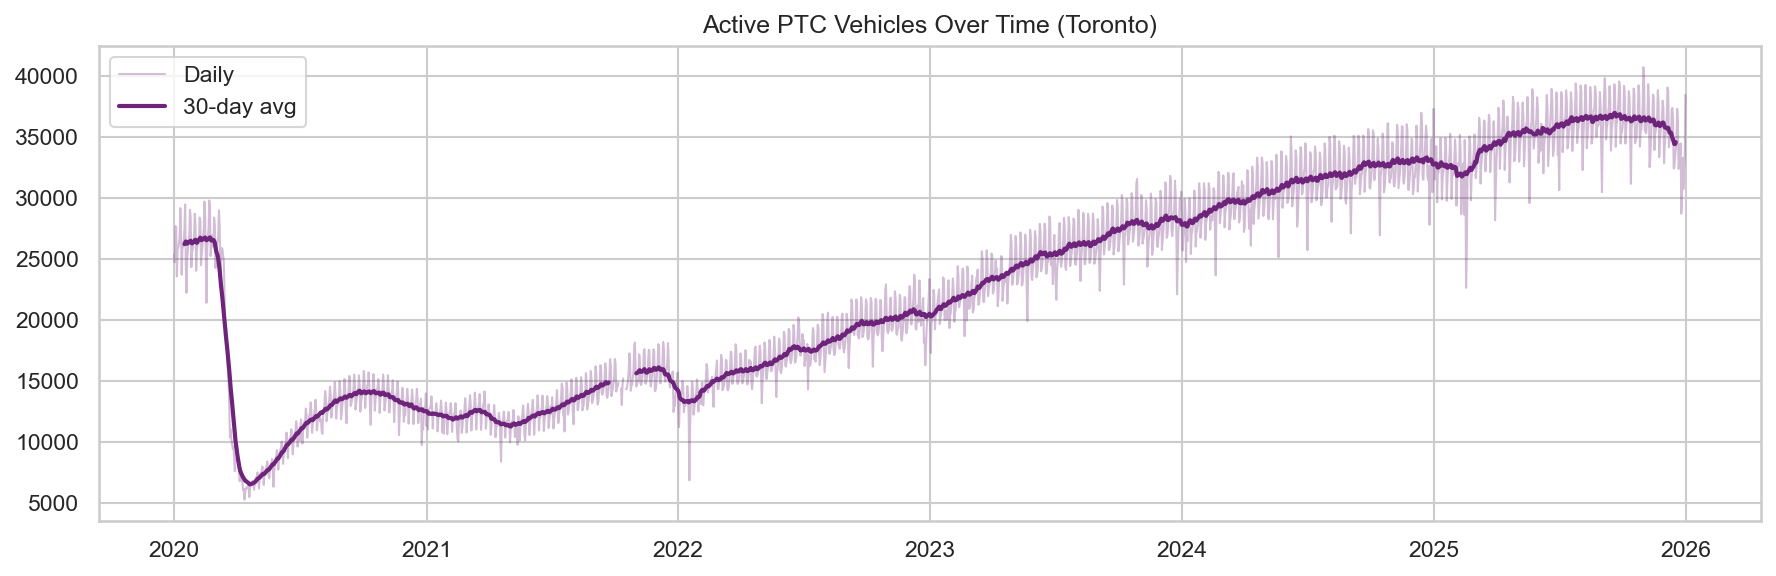

In [6]:
# 1. Active vehicles over time
fig, ax = plt.subplots()
ax.plot(df["dt"], df["active_vehicles"],
        color="#6d247a", linewidth=1, alpha=0.3, label="Daily")
ax.plot(df["dt"], df["active_vehicles"].rolling(30, center=True).mean(),
        color="#6d247a", linewidth=2, label="30-day avg")
ax.set_title("Active PTC Vehicles Over Time (Toronto)")
fmt_xaxis(ax)
ax.legend()
plt.tight_layout()
#plt.savefig("1_active_vehicles.png")
plt.show()

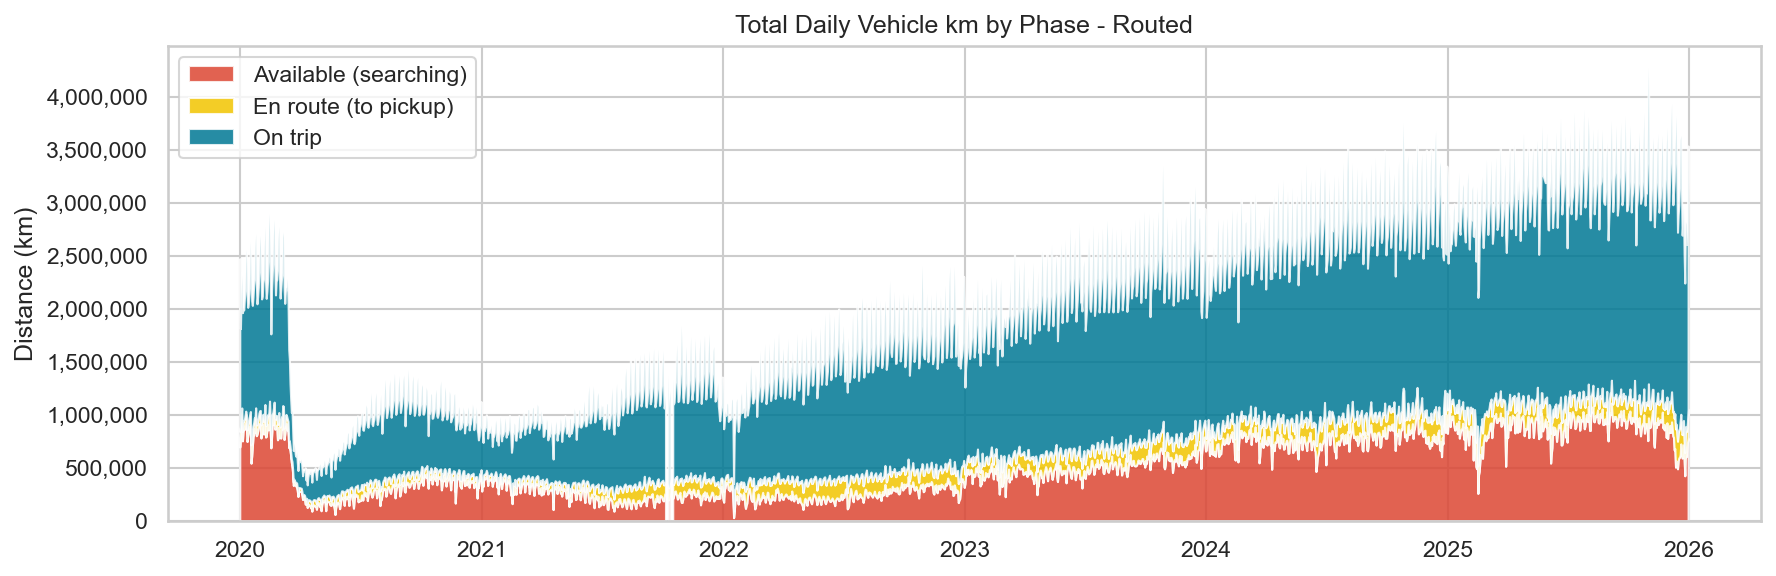

In [7]:
# 2. Stacked area – total daily km by phase 
dist_cols = ["dist_available_routed", "dist_enroute_routed", "dist_ontrip_routed"]
labels    = ["Available (searching)", "En route (to pickup)", "On trip"]
colors    = ["#dc4633", "#f1c500", "#007894"]

fig, ax = plt.subplots()
ax.stackplot(
    df["dt"],
    [df[c] for c in dist_cols],
    labels=labels, colors=colors, alpha=0.85,
)
ax.set_title("Total Daily Vehicle km by Phase - Routed")
ax.set_ylabel("Distance (km)")
fmt_xaxis(ax)
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

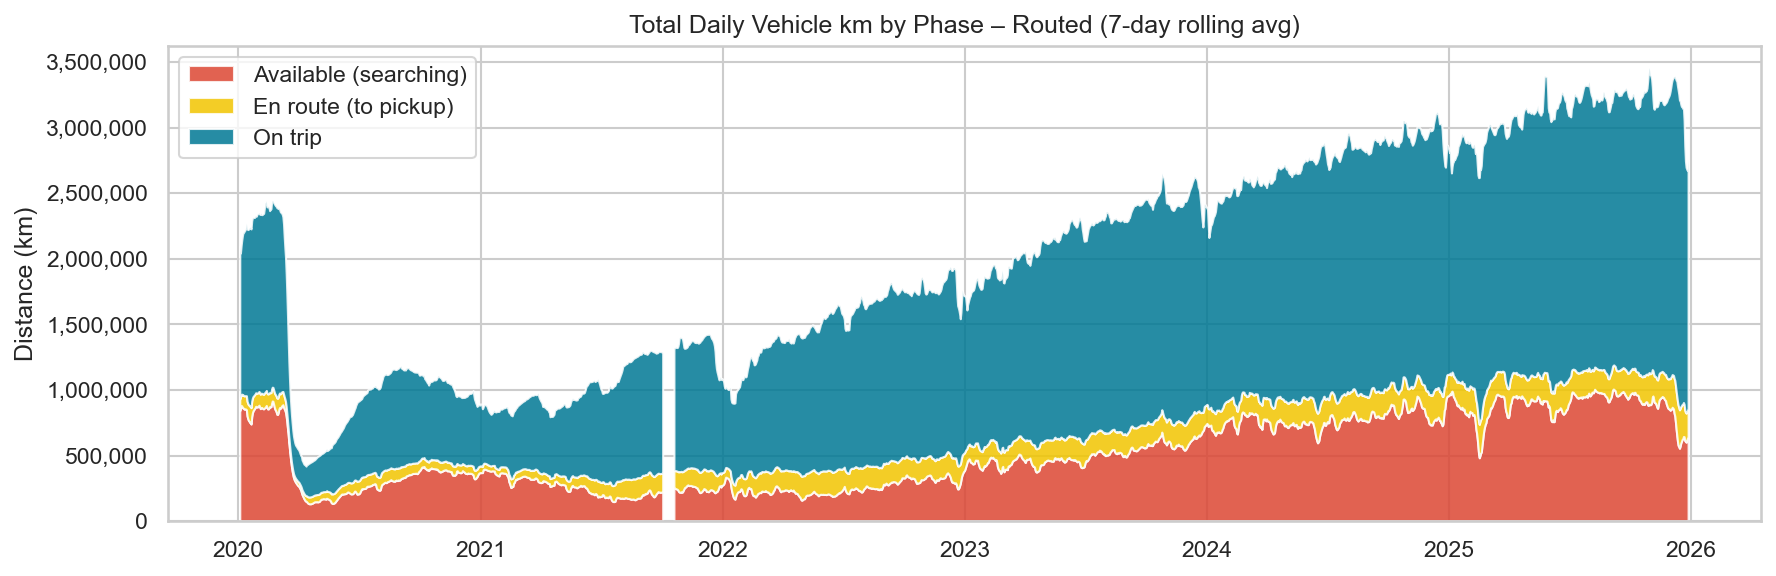

In [8]:
# 2. Stacked area – total daily km by phase 
dist_cols = ["dist_available_routed", "dist_enroute_routed", "dist_ontrip_routed"]
labels    = ["Available (searching)", "En route (to pickup)", "On trip"]
colors    = ["#dc4633", "#f1c500", "#007894"]

df_dist = df[["dt"] + dist_cols].copy()
for col in dist_cols:
    df_dist[col] = df_dist[col].rolling(7, center=True).mean()

fig, ax = plt.subplots()
ax.stackplot(
    df_dist["dt"],
    [df_dist[c] for c in dist_cols],
    labels=labels, colors=colors, alpha=0.85,
)
ax.set_title("Total Daily Vehicle km by Phase – Routed (7-day rolling avg)")
ax.set_ylabel("Distance (km)")
fmt_xaxis(ax)
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
#plt.savefig("2_stacked_dist.png")
plt.show()

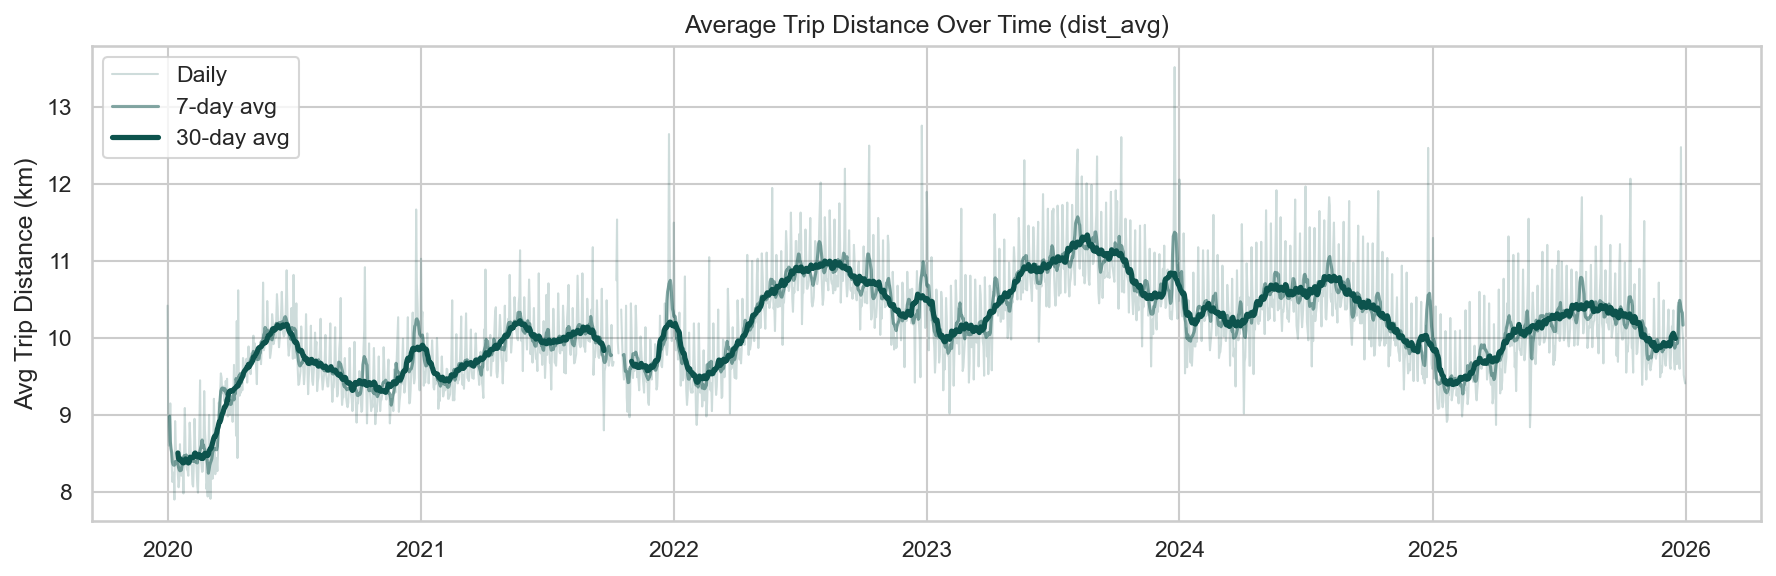

In [9]:
# 3. Average trip distance over time 
# dist_avg: average distance per completed trip in km 
df["dist_avg_7d"]  = df["dist_avg"].rolling(7,  center=True).mean()
df["dist_avg_30d"] = df["dist_avg"].rolling(30, center=True).mean()

fig, ax = plt.subplots()
ax.plot(df["dt"], df["dist_avg"],
        color="#0d534d", alpha=0.2, linewidth=1, label="Daily")
ax.plot(df["dt"], df["dist_avg_7d"],
        color="#0d534d", alpha=0.5, linewidth=1.5, label="7-day avg")
ax.plot(df["dt"], df["dist_avg_30d"],
        color="#0d534d", linewidth=2.5, label="30-day avg")
ax.set_title("Average Trip Distance Over Time (dist_avg)")
ax.set_ylabel("Avg Trip Distance (km)")
fmt_xaxis(ax)
ax.legend()
plt.tight_layout()
#plt.savefig("3_avg_trip_distance.png")
plt.show()

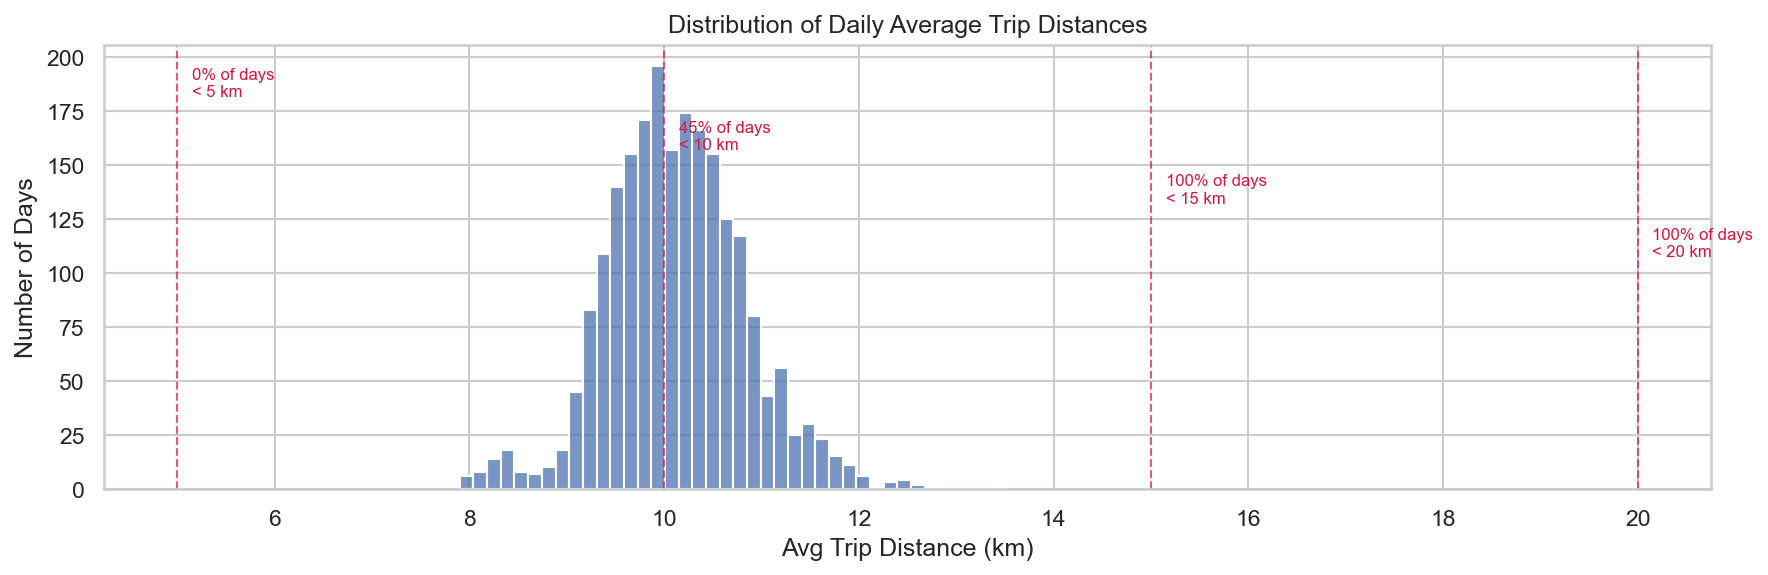

In [10]:
# 4. Distribution of daily avg trip distances
clean = df["dist_avg"].dropna()

fig, ax = plt.subplots()
sns.histplot(clean, bins=40, color="#4C72B0", ax=ax)

thresholds = [5, 10, 15, 20]
ymax = ax.get_ylim()[1]
for i, t in enumerate(thresholds):
    pct = (clean < t).mean() * 100
    ax.axvline(t, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(t + 0.15, ymax * (0.95 - i * 0.12),
            f"{pct:.0f}% of days\n< {t} km",
            color="crimson", fontsize=8, va="top")

ax.set_title("Distribution of Daily Average Trip Distances")
ax.set_xlabel("Avg Trip Distance (km)")
ax.set_ylabel("Number of Days")
plt.tight_layout()
#plt.savefig("4_trip_dist_histogram.png")
plt.show()

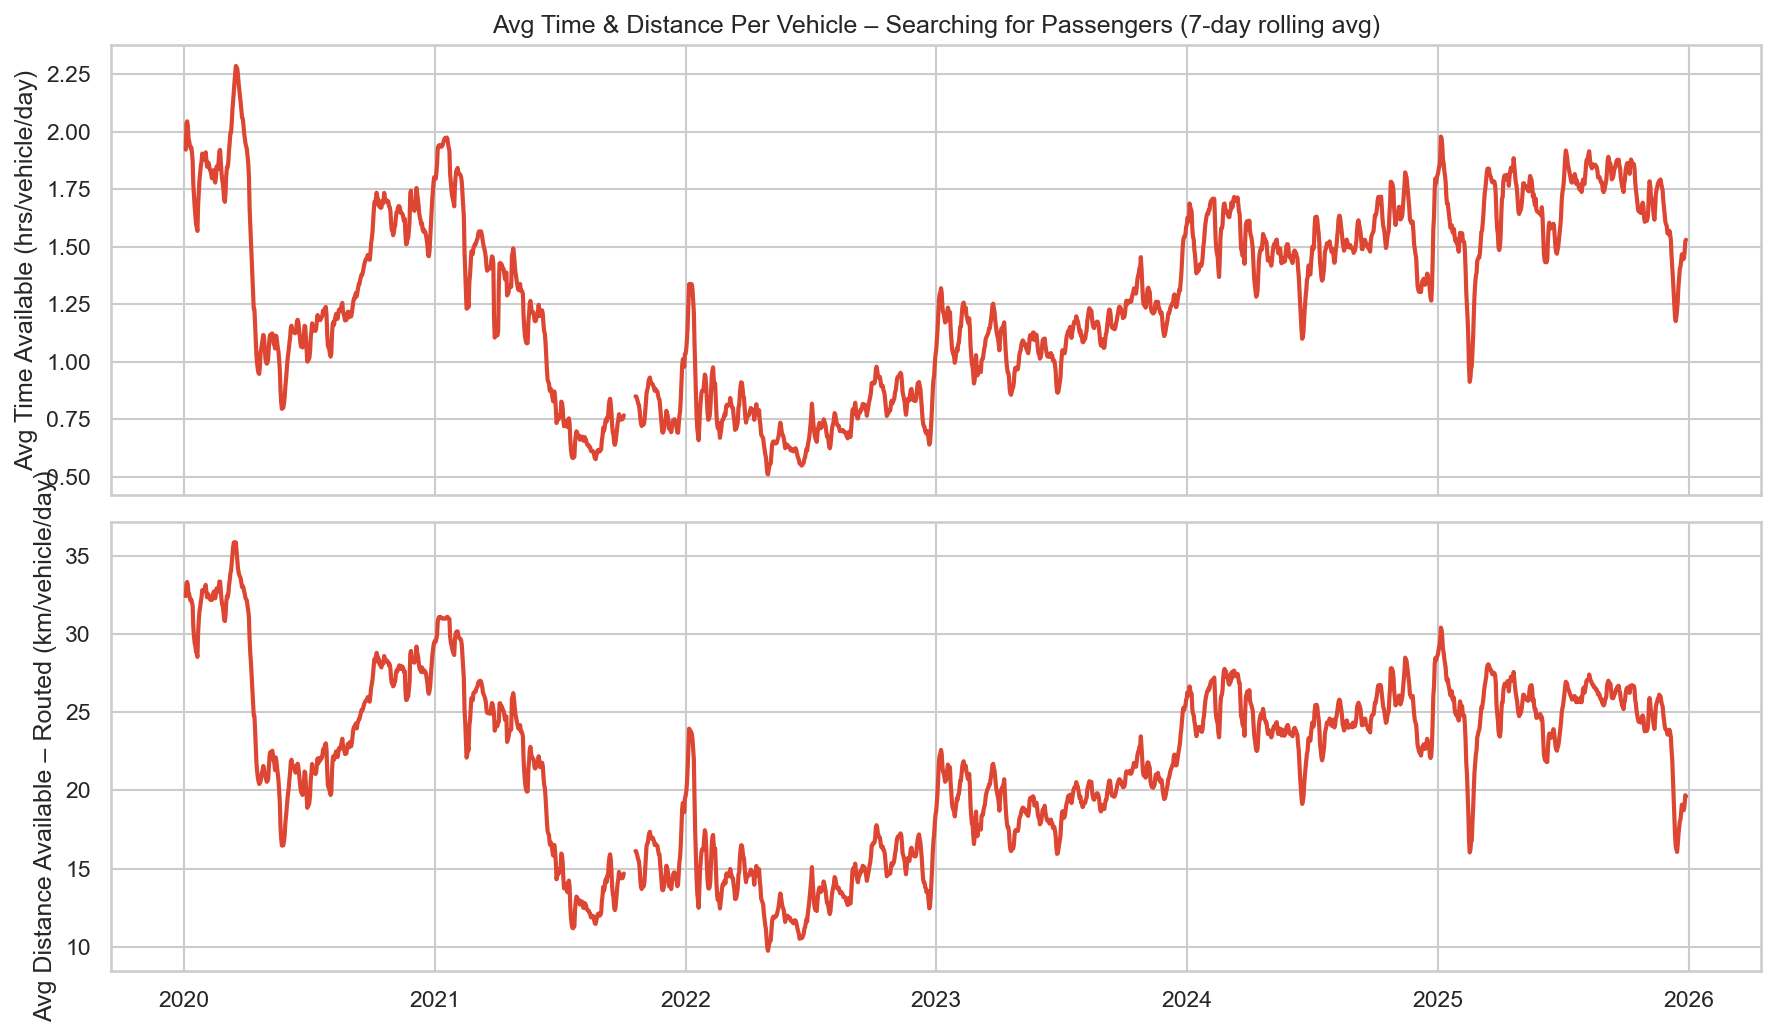

In [11]:
# 5. Avg time & distance per vehicle when 'available' 
df["avg_time_available_hrs"] = (df["time_available"] / 60) / df["active_vehicles"]
df["avg_dist_available"]     = df["dist_available_routed"] / df["active_vehicles"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(df["dt"], df["avg_time_available_hrs"].rolling(7, center=True).mean(),
         color="#dc4633", linewidth=2)
ax1.set_title("Avg Time & Distance Per Vehicle – Searching for Passengers (7-day rolling avg)")
ax1.set_ylabel("Avg Time Available (hrs/vehicle/day)")

ax2.plot(df["dt"], df["avg_dist_available"].rolling(7, center=True).mean(),
         color="#dc4633", linewidth=2)
ax2.set_ylabel("Avg Distance Available – Routed (km/vehicle/day)")
fmt_xaxis(ax2)

plt.tight_layout()
#plt.savefig("5_available_per_vehicle.png")
plt.show()

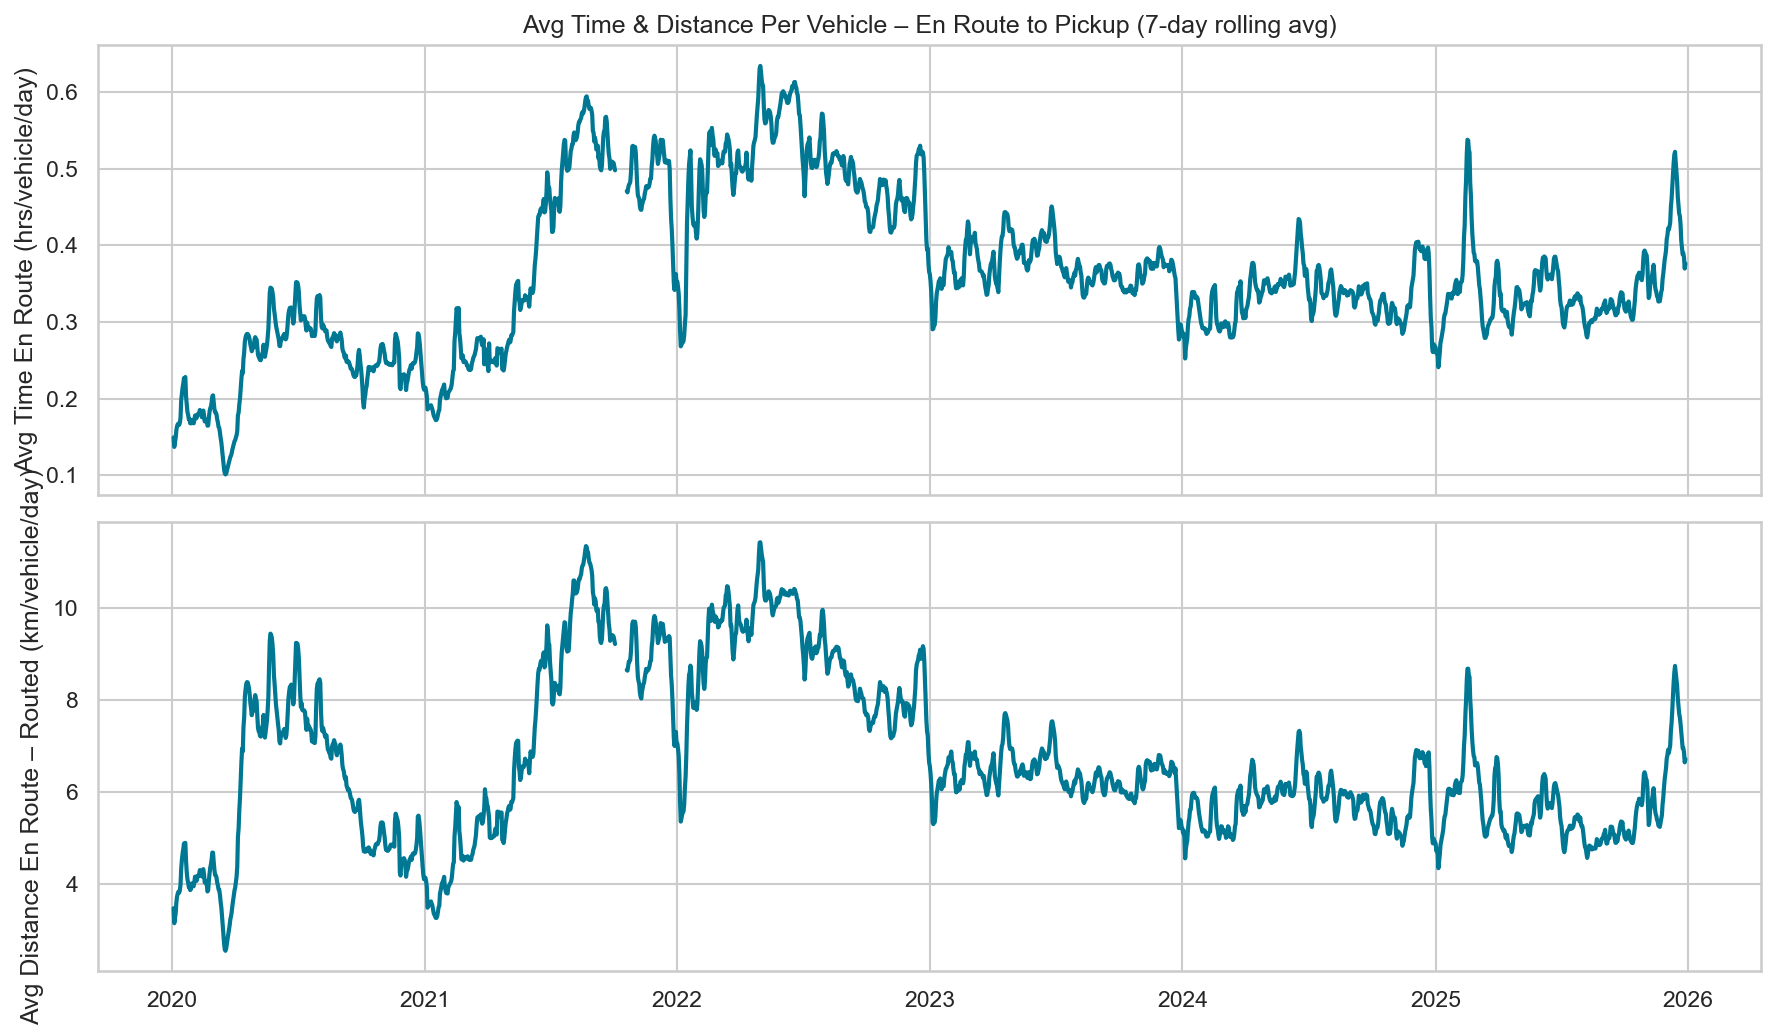

In [12]:
# 6. Avg time & distance per vehicle enroute
df["avg_time_enroute_hrs"] = (df["time_enroute"] / 60) / df["active_vehicles"]
df["avg_dist_enroute"]     = df["dist_enroute_routed"] / df["active_vehicles"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(df["dt"], df["avg_time_enroute_hrs"].rolling(7, center=True).mean(),
         color="#007894", linewidth=2)
ax1.set_title("Avg Time & Distance Per Vehicle – En Route to Pickup (7-day rolling avg)")
ax1.set_ylabel("Avg Time En Route (hrs/vehicle/day)")

ax2.plot(df["dt"], df["avg_dist_enroute"].rolling(7, center=True).mean(),
         color="#007894", linewidth=2)
ax2.set_ylabel("Avg Distance En Route – Routed (km/vehicle/day)")
fmt_xaxis(ax2)

plt.tight_layout()
#plt.savefig("6_enroute_per_vehicle.png")
plt.show()

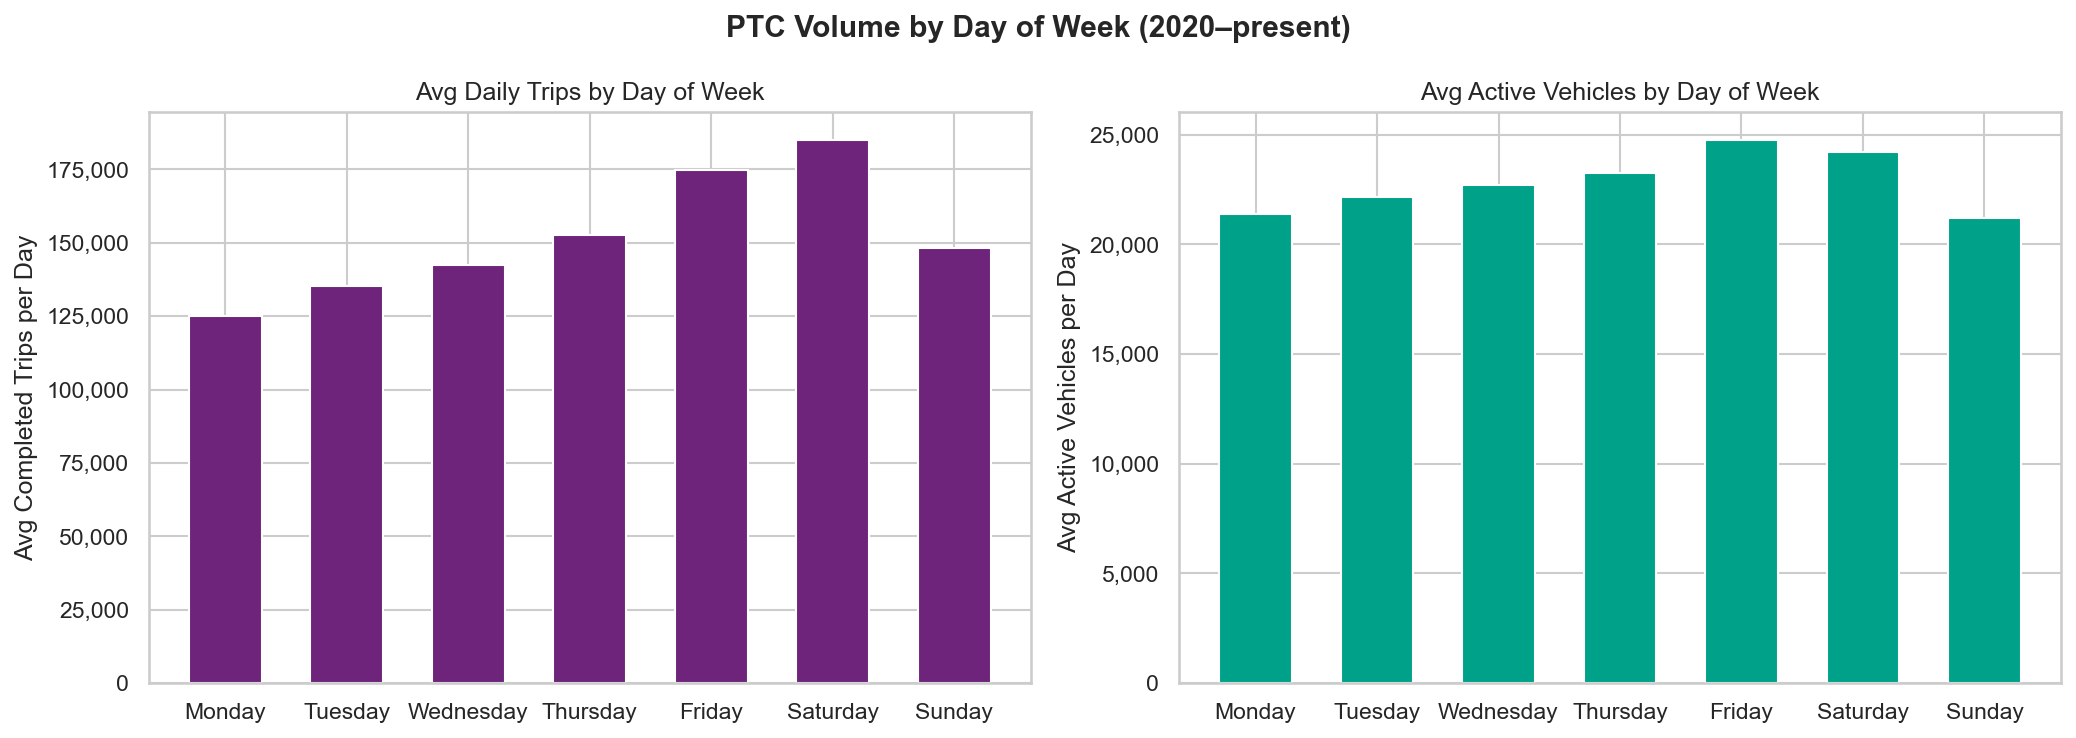

In [13]:
# Weekday/weekend: Volume
df["day_of_week"] = df["dt"].dt.day_name()
df["day_order"]   = df["dt"].dt.dayofweek  # 0=Monday, 6=Sunday

dow_vol = (
    df.groupby(["day_of_week", "day_order"])[["reported_trips_started", "active_vehicles"]]
    .mean()
    .reset_index()
    .sort_values("day_order")
)

days = dow_vol["day_of_week"].tolist()
x    = range(len(days))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Trips started
bars1 = ax1.bar(x, dow_vol["reported_trips_started"],
                color="#6d247a", width=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(days)
ax1.set_ylabel("Avg Completed Trips per Day")
ax1.set_title("Avg Daily Trips by Day of Week")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

# Active vehicles
bars2 = ax2.bar(x, dow_vol["active_vehicles"],
                color="#00a189", width=0.6)
ax2.set_xticks(x)
ax2.set_xticklabels(days)
ax2.set_ylabel("Avg Active Vehicles per Day")
ax2.set_title("Avg Active Vehicles by Day of Week")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.suptitle("PTC Volume by Day of Week (2020–present)", fontweight="bold")
plt.tight_layout()
plt.show()


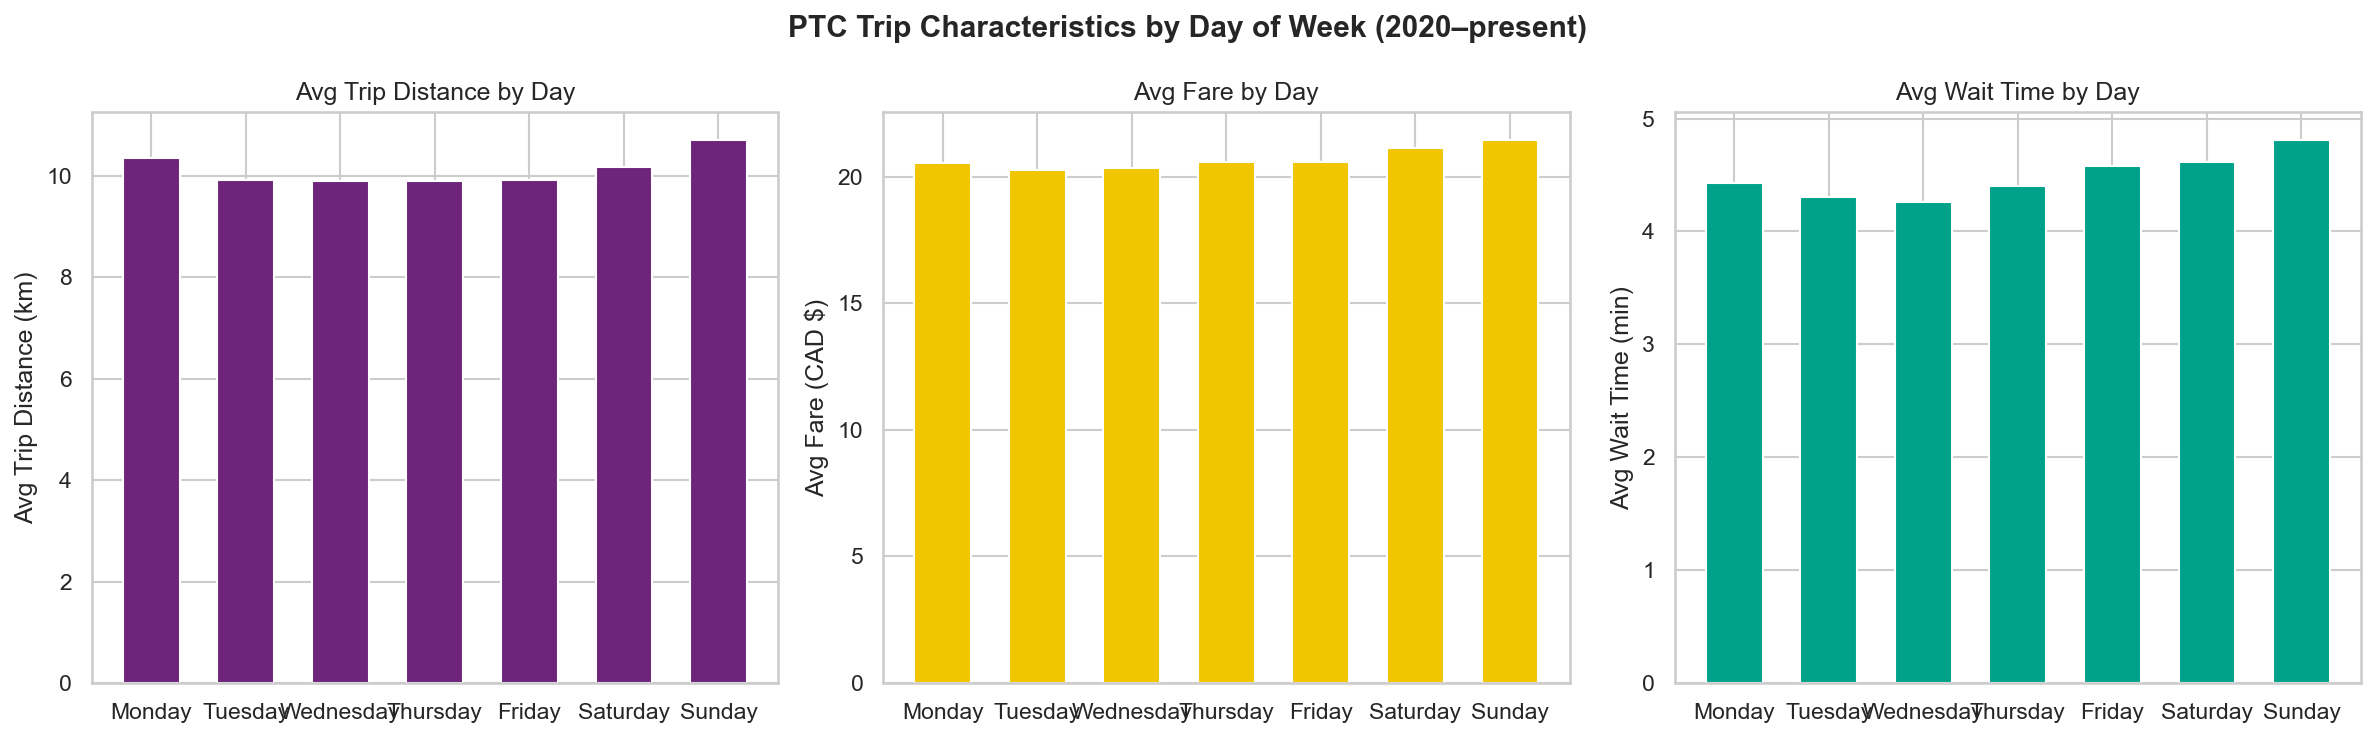

In [14]:
# ── Weekday/weekend: Trip characteristics ─────────────────────────────────────
dow_trip = (
    df.groupby(["day_of_week", "day_order"])[["dist_avg", "fare_avg",
                                               "waittime_nonwav_avg"]]
    .mean()
    .reset_index()
    .sort_values("day_order")
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, ylabel, title, color in zip(
    (ax1, ax2, ax3),
    ("dist_avg", "fare_avg", "waittime_nonwav_avg"),
    ("Avg Trip Distance (km)", "Avg Fare (CAD $)", "Avg Wait Time (min)"),
    ("Avg Trip Distance by Day", "Avg Fare by Day", "Avg Wait Time by Day"),
    ("#6d247a", "#f1c500", "#00a189"),
):
    ax.bar(x, dow_trip[col], color=color, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(days)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.suptitle("PTC Trip Characteristics by Day of Week (2020–present)", fontweight="bold")
plt.tight_layout()
plt.show()

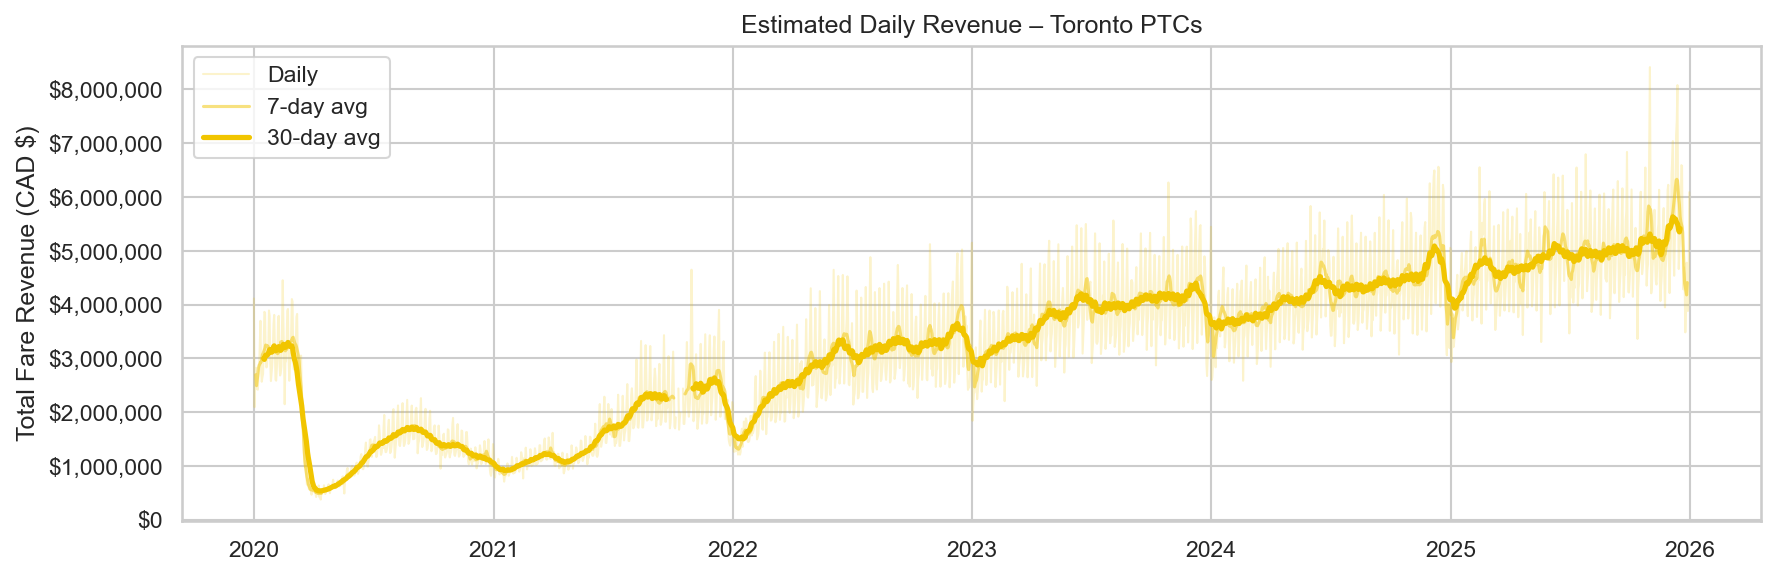

In [19]:
# ── Avg fare over time ────────────────────────────────────────────────────────
df["daily_revenue"] = df["fare_avg"] * df["reported_trips_started"]

df["revenue_7d"]  = df["daily_revenue"].rolling(7,  center=True).mean()
df["revenue_30d"] = df["daily_revenue"].rolling(30, center=True).mean()

fig, ax = plt.subplots()
ax.plot(df["dt"], df["daily_revenue"],
        color="#f1c500", alpha=0.2, linewidth=1, label="Daily")
ax.plot(df["dt"], df["revenue_7d"],
        color="#f1c500", alpha=0.5, linewidth=1.5, label="7-day avg")
ax.plot(df["dt"], df["revenue_30d"],
        color="#f1c500", linewidth=2.5, label="30-day avg")
ax.set_title("Estimated Daily Revenue – Toronto PTCs")
ax.set_ylabel("Total Fare Revenue (CAD $)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
fmt_xaxis(ax)
ax.legend()
plt.tight_layout()
plt.show()

Removed 136 trips (0.0002% of total)


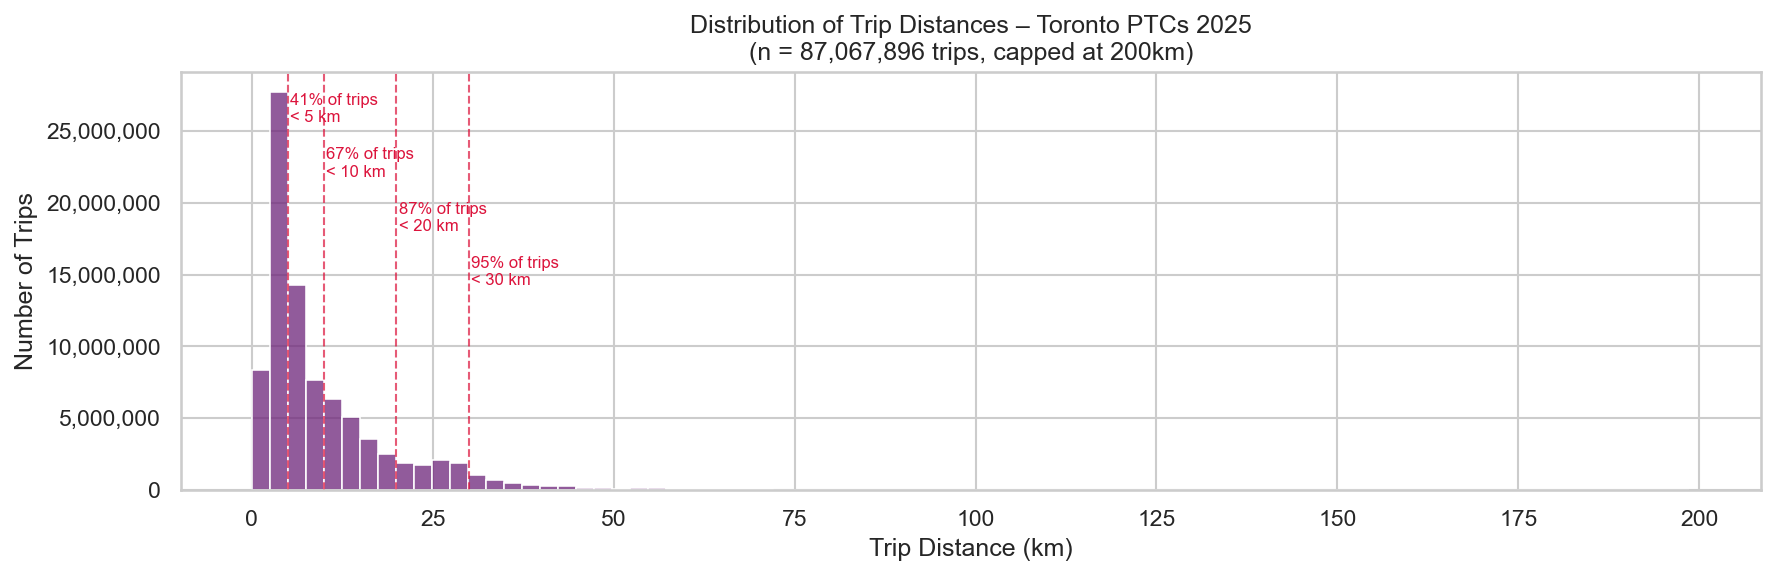

In [16]:
import glob
import numpy as np

# Load all 12 months
files = sorted(glob.glob("data/trips_2025/trips_2025*.csv"))
trips = pd.concat([pd.read_csv(f, parse_dates=["dt", "pickup_hr"]) for f in files],
                  ignore_index=True)

# Build weighted distribution
# Each row represents `trips_total` trips with avg distance `distance_avg`
# repeat each distance_avg value trips_total times to approximate the full distribution
trips_clean = trips.dropna(subset=["distance_avg", "trips_total"])
trips_clean = trips_clean[trips_clean["distance_avg"] > 0]

# Repeat each avg distance by its trip count to get a weighted sample
weighted_dist = np.repeat(
    trips_clean["distance_avg"].values,
    trips_clean["trips_total"].astype(int).values
)

# remove trips over 200km
weighted_dist_clean = weighted_dist[weighted_dist <= 200] 

print(f"Removed {len(weighted_dist) - len(weighted_dist_clean):,} trips "
      f"({(1 - len(weighted_dist_clean)/len(weighted_dist))*100:.4f}% of total)")

fig, ax = plt.subplots()
sns.histplot(weighted_dist_clean, bins=80, color="#6d247a", ax=ax)

thresholds = [5, 10, 20, 30]
ymax = ax.get_ylim()[1]
for i, t in enumerate(thresholds):
    pct = (weighted_dist_clean < t).mean() * 100
    ax.axvline(t, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(t + 0.3, ymax * (0.95 - i * 0.13),
            f"{pct:.0f}% of trips\n< {t} km",
            color="crimson", fontsize=8, va="top")

ax.set_title(f"Distribution of Trip Distances – Toronto PTCs 2025\n"
             f"(n = {len(weighted_dist_clean):,} trips, capped at 200km)")
ax.set_xlabel("Trip Distance (km)")
ax.set_ylabel("Number of Trips")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()
plt.show()

In [17]:
print(pd.Series(weighted_dist).describe())
print(f"\nTrips > 100km: {(weighted_dist > 100).sum():,}")
print(f"Trips > 50km:  {(weighted_dist > 50).sum():,}")
print(f"Trips > 30km:  {(weighted_dist > 30).sum():,}")

count    8.706803e+07
mean     1.001011e+01
std      9.755830e+00
min      1.000000e-01
25%      3.520000e+00
50%      6.270000e+00
75%      1.291000e+01
max      9.282400e+03
dtype: float64

Trips > 100km: 2,227
Trips > 50km:  671,210
Trips > 30km:  3,970,388


In [18]:
percentiles = [95, 97, 99, 99.5, 99.9, 99.99]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(weighted_dist, p):.1f} km")

95th percentile: 29.4 km
97th percentile: 33.5 km
99th percentile: 45.8 km
99.5th percentile: 55.9 km
99.9th percentile: 69.5 km
99.99th percentile: 86.0 km
